# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Штурин Захарій Михайлович'
ГРУПА = 'ШІ-34'
ВАРІАНТ = 6

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Штурин Захарій Михайлович, ШІ-34, варіант 6
ваш потік:                   P>30
ваша пара для графіка 3:     густина вітру та потік P>1
ваш агрегат для етапу 4:     мінімум
ваше додаткове питання:      У яку добу середнє значення вашого потоку було найбільшим? А найменшим?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
pd.read_excel(ФАЙЛ).head()

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** Ми отримали саме такі результати, бо перші рядки це метадані до таблиці

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print(RAW.head(30))

    0                                                  1    2    3     4         5        6      7      8      9       10      11      12     13     14  15  \
0  NaN        ftp://ftp.swpc.noaa.gov/pub/lists/particle/  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
1  NaN                                                NaN  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
2  NaN                :Data_list: 20170901_Gs_part_5m.txt  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
3  NaN                     :Created: 2017 Sep 02 0011 UTC  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
4  NaN  # Prepared by the U.S. Dept. of Commerce, NOAA...  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN     NaN     NaN     NaN    NaN    NaN NaN   
5  NaN  # Please send comments and suggestions

### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** 3 таблиці: 
Таблиця A: 7202 рядочки;
Таблиця B: 26 рядочки;
ТАблиця C: 602 рядочки;

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# ВАШ КОД
print(RAW.head(26).to_string())

    0                                                                                1    2    3     4         5        6      7      8      9      10     11     12     13     14  15                                                                                16   17   18   19  20  21  22  23  24  25                                                                               26   27   28   29   30   31
0  NaN                                      ftp://ftp.swpc.noaa.gov/pub/lists/particle/  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN NaN                                                                               NaN  NaN  NaN  NaN NaN NaN NaN NaN NaN NaN                                                     http://umtof.umd.edu/pm/crn/  NaN  NaN  NaN  NaN  NaN
1  NaN                                                                              NaN  NaN  NaN   NaN       NaN      NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN N

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
|A| GOES-15, NOAA Space Weather Prediction Center | Particles = Protons/cm2-s-sr; Electrons = Electrons/cm2-s-sr |
| B | Quarterly Daily Solar Data | Radio Flux 10.7 |
| C | SOHO CELIAS Proton Monitor | Proton speed [km/sec]; Proton density [protons per cubic centimeter] |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
A = RAW.iloc[26:7726, 1:15].copy()
B = RAW.iloc[27:52, 16:20].copy()
C = RAW.iloc[27:628, 24:32].copy()

A.columns = [
    "year", "month", "day", "time",
    "julian_day", "seconds",
    "protons_gt_1MeV",
    "protons_gt_5MeV",
    "protons_gt_10MeV",
    "protons_gt_30MeV",
    "protons_gt_50MeV",
    "protons_gt_100MeV",
    "electrons_gt_0_8MeV",
    "electrons_gt_2_0MeV"
]

B.columns = [
    "year", "month", "day", "F10_7"
]


C.columns = [
    "index1","index2", "year", "month", "day",
    "hour", "speed_km_s", "density_protons_cm3"
]

A = A.apply(pd.to_numeric, errors="coerce")
B = B.apply(pd.to_numeric, errors="coerce")
C = C.apply(pd.to_numeric, errors="coerce")


print(A.head())
print(B.head())
print(C.head())

    year  month  day  time  julian_day  seconds  protons_gt_1MeV  protons_gt_5MeV  protons_gt_10MeV  protons_gt_30MeV  protons_gt_50MeV  protons_gt_100MeV  electrons_gt_0_8MeV  electrons_gt_2_0MeV
26  2017      8   28     0       57993        0            12.00            0.260             0.180            0.1140            0.1040             0.0793              23600.0               1180.0
27  2017      8   28     5       57993      300            19.40            0.690             0.314            0.1120            0.0612             0.0251              23100.0               1160.0
28  2017      8   28    10       57993      600             8.48            0.168             0.130            0.0717            0.0614             0.0304              22200.0               1090.0
29  2017      8   28    15       57993      900            15.40            0.566             0.198            0.0926            0.0568             0.0251              20400.0                997.0
30  2017      8

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
# ВАШ КОД
A["ts"] = pd.to_datetime(
    A["year"].astype(str) + "-" +
    A["month"].astype(str) + "-" +
    A["day"].astype(str) + " " +
    A["time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    errors="coerce"
)

B["ts"] = pd.to_datetime(
    B["year"].astype(str) + "-" +
    B["month"].astype(str) + "-" +
    B["day"].astype(str),
    format="%Y-%m-%d",
    errors="coerce"
)

C["ts"] = pd.to_datetime(
    "20" + C["year"].astype(str) + "-" +
    C["month"].astype(str) + "-" +
    C["day"].astype(str) + " " +
    C["hour"].astype(str),
    format="%Y-%m-%d %H",
    errors="coerce"
)

print("A:", A["ts"].min(), "—", A["ts"].max())
print("B:", B["ts"].min(), "—", B["ts"].max())
print("C:", C["ts"].min(), "—", C["ts"].max())

A: 2017-08-28 00:00:00 — 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 — 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 — 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
# ВАШ КОД
for name, df in [("A", A), ("B", B), ("C", C)]:
    print(f"=== {name} ===")

    print("= Розмір =")
    print(df.shape)
    print("= Типи даних =")
    print(df.dtypes)
    print("= Пусті =")
    print(df.isna().sum())
    print("= Дуплікати =")
    print(df.duplicated().sum())
    print("= Інфа =")
    print(df.describe())

=== A ===
= Розмір =
(7200, 15)
= Типи даних =
year                            int64
month                           int64
day                             int64
time                            int64
julian_day                      int64
seconds                         int64
protons_gt_1MeV               float64
protons_gt_5MeV               float64
protons_gt_10MeV              float64
protons_gt_30MeV              float64
protons_gt_50MeV              float64
protons_gt_100MeV             float64
electrons_gt_0_8MeV           float64
electrons_gt_2_0MeV           float64
ts                     datetime64[us]
dtype: object
= Пусті =
year                   0
month                  0
day                    0
time                   0
julian_day             0
seconds                0
protons_gt_1MeV        3
protons_gt_5MeV        3
protons_gt_10MeV       3
protons_gt_30MeV       3
protons_gt_50MeV       3
protons_gt_100MeV      3
electrons_gt_0_8MeV    3
electrons_gt_2_0MeV    3
ts       

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
# ВАШ КОД
print(C[C["speed_km_s"] < 0]["speed_km_s"])
print((C["speed_km_s"] < 0).sum())

print(C[C["density_protons_cm3"] < 0]["density_protons_cm3"])
print((C["density_protons_cm3"] < 0).sum())

C.loc[C["speed_km_s"] < 0, "speed_km_s"] = float("nan")
C.loc[C["density_protons_cm3"] < 0, "density_protons_cm3"] = float("nan")

print(C.describe())

202   -1
203   -1
204   -1
205   -1
206   -1
207   -1
208   -1
209   -1
Name: speed_km_s, dtype: int64
8
202   -1.0
203   -1.0
204   -1.0
205   -1.0
206   -1.0
207   -1.0
208   -1.0
209   -1.0
Name: density_protons_cm3, dtype: float64
8
           index1      index2   year       month         day        hour  speed_km_s  density_protons_cm3                   ts
count  601.000000  601.000000  601.0  601.000000  601.000000  601.000000  593.000000           593.000000                  601
mean    11.480865   11.480865   17.0    8.840266   13.973378   11.480865  513.394604             2.960371  2017-09-09 12:00:00
min      0.000000    0.000000   17.0    8.000000    1.000000    0.000000  277.000000             0.100000  2017-08-28 00:00:00
25%      5.000000    5.000000   17.0    9.000000    7.000000    5.000000  449.000000             1.800000  2017-09-03 06:00:00
50%     11.000000   11.000000   17.0    9.000000   13.000000   11.000000  520.000000             2.500000  2017-09-09 12:00:00
7

**Відповідь 3.2:** значення -1 використовували для позначення пропущених значень, у таблиці C їх виявилось 8 і помінявши їх, ми збільшили більшітсь характеристик описаних у C.describe() 

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
# ВАШ КОД
A.describe()

,year,month,day,time,julian_day,seconds,protons_gt_1MeV,protons_gt_5MeV,protons_gt_10MeV,protons_gt_30MeV,protons_gt_50MeV,protons_gt_100MeV,electrons_gt_0_8MeV,electrons_gt_2_0MeV,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


**Відповідь 3.3:** Мабуть, всі часові(рік, місяць, дата і тд), оскільки вони не несуть ніякого аналізу щодо наших даних 

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
# ВАШ КОД
A_hour = A.set_index("ts")

flux_cols = [
    "protons_gt_1MeV",
    "protons_gt_5MeV",
    "protons_gt_10MeV",
    "protons_gt_30MeV",
    "protons_gt_50MeV",
    "protons_gt_100MeV",
    "electrons_gt_0_8MeV",
    "electrons_gt_2_0MeV"
]

A_hour = A_hour[flux_cols].resample("1h").agg(["mean", "max"])

print(A_hour.head(30))

                    protons_gt_1MeV        protons_gt_5MeV        protons_gt_10MeV        protons_gt_30MeV         protons_gt_50MeV         protons_gt_100MeV         electrons_gt_0_8MeV           \
                               mean    max            mean    max             mean    max             mean     max             mean     max              mean     max                mean      max   
ts                                                                                                                                                                                                   
2017-08-28 00:00:00        9.778333  19.40        0.324917  0.690         0.192917  0.314         0.098850  0.2240         0.077583  0.1780          0.040692  0.0793        20941.666667  23600.0   
2017-08-28 01:00:00        7.994167  13.60        0.291667  0.512         0.156583  0.259         0.072583  0.0919         0.058700  0.0798          0.029950  0.0471        18091.666667  20600.0   
2017-08-28

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

                       min      mean
ts                                  
2017-09-15 00:00:00  0.904  1.003167
2017-09-15 01:00:00  0.770  0.883000
2017-09-15 02:00:00  0.678  0.866917
2017-09-15 03:00:00  0.650  0.824583
2017-09-15 04:00:00  0.568  0.774500
2017-09-15 05:00:00  0.694  0.869833
2017-09-15 06:00:00  0.582  0.795250
2017-09-15 07:00:00  0.648  0.783667
2017-09-15 08:00:00  0.580  0.781250
2017-09-15 09:00:00  0.467  0.725250
2017-09-15 10:00:00  0.537  0.771583
2017-09-15 11:00:00  0.522  0.694000
2017-09-15 12:00:00  0.472  0.596167
2017-09-15 13:00:00  0.519  0.634917
2017-09-15 14:00:00  0.424  0.564917
2017-09-15 15:00:00  0.412  0.550167
2017-09-15 16:00:00  0.390  0.546500
2017-09-15 17:00:00  0.339  0.497917
2017-09-15 18:00:00  0.269  0.506667
2017-09-15 19:00:00  0.434  0.517417
2017-09-15 20:00:00  0.217  0.439500
2017-09-15 21:00:00  0.219  0.337500
2017-09-15 22:00:00  0.336  0.451583
2017-09-15 23:00:00  0.363  0.426583


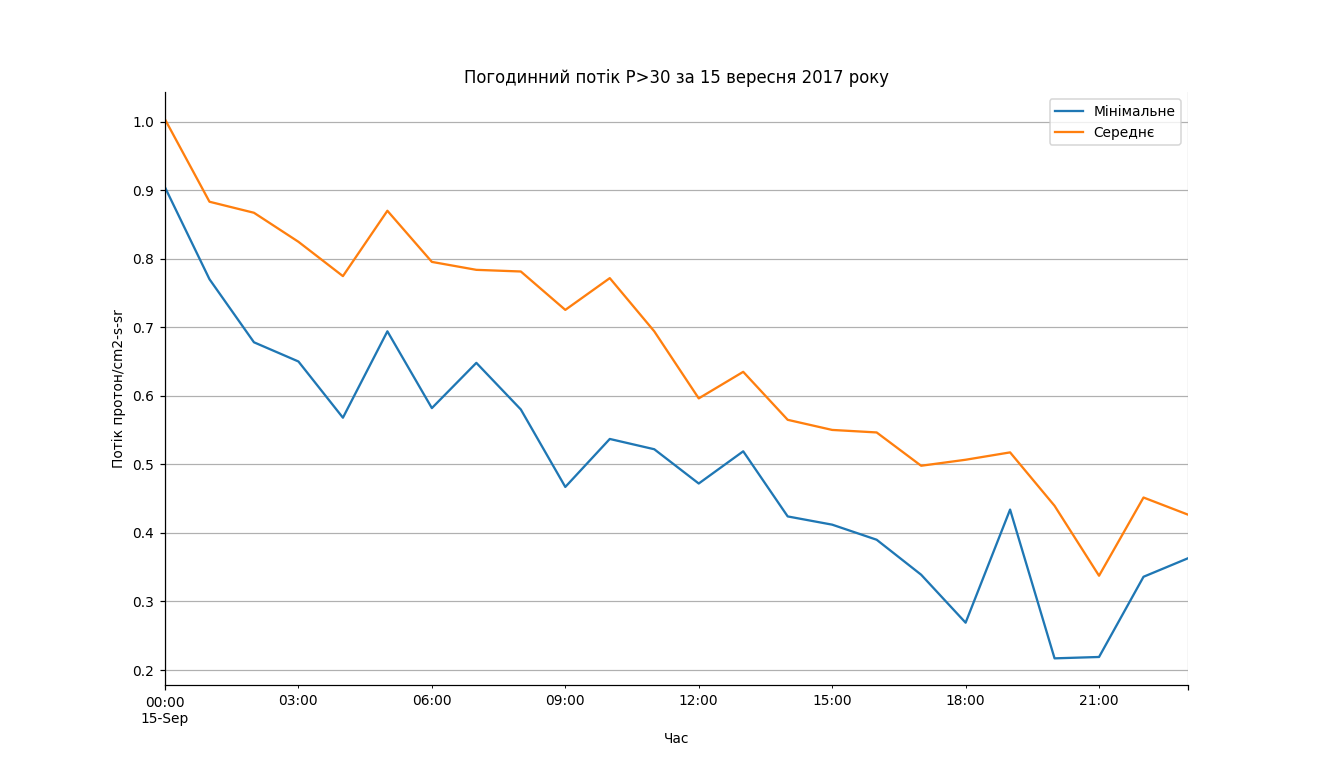

In [15]:
# ВАШ КОД
%matplotlib widget
day = A[A["ts"].dt.date == pd.Timestamp("2017-09-15").date()].copy()
day = day.set_index("ts")

protons_gt_30MeV_day = day["protons_gt_30MeV"].resample("1h").agg(["min", "mean"])
#print(protons_gt_30MeV_day)

protons_gt_30MeV_day.plot(figsize=(12,7))
plt.title("Погодинний потік P>30 за 15 вересня 2017 року")
plt.xlabel("Час")
plt.ylabel("Потік протон/cm2-s-sr")
plt.legend(["Мінімальне", "Середнє"])
plt.grid()
plt.show()

**Відповідь 4.2:** крива мінімальних значень показує найменший потік P>30 протягом кожної години, а крива середній значень - середній рівень потоку. Значна різниця може бути, якщо протягом години сонячна енергія буде дуже коливатись, тоді середнє значення краще охарактеризує потік

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
# ВАШ КОД
A_hour = A.set_index("ts")

A_hour_cols = [
    "protons_gt_1MeV",
    "protons_gt_5MeV",
    "protons_gt_10MeV",
    "protons_gt_30MeV",
    "protons_gt_50MeV",
    "protons_gt_100MeV",
    "electrons_gt_0_8MeV",
    "electrons_gt_2_0MeV"
]

A_hour = A_hour[A_hour_cols].resample("1h").mean()

B_hour = B.set_index("ts")
B_hour = B_hour[["F10_7"]].resample("1h").ffill()

C_hour = C.set_index("ts")
C_hour = C_hour[["speed_km_s", "density_protons_cm3"]]


print(A_hour.head(30))
print(B_hour.head(30))
print(C_hour.head(30))

                     protons_gt_1MeV  protons_gt_5MeV  protons_gt_10MeV  protons_gt_30MeV  protons_gt_50MeV  protons_gt_100MeV  electrons_gt_0_8MeV  electrons_gt_2_0MeV
ts                                                                                                                                                                      
2017-08-28 00:00:00         9.778333         0.324917          0.192917          0.098850          0.077583           0.040692         20941.666667          1011.583333
2017-08-28 01:00:00         7.994167         0.291667          0.156583          0.072583          0.058700           0.029950         18091.666667           713.000000
2017-08-28 02:00:00         6.099167         0.283000          0.177667          0.084450          0.069642           0.035025         14108.333333           380.833333
2017-08-28 03:00:00         4.752500         0.236833          0.166333          0.087658          0.068092           0.035517         12766.666667        

In [17]:
M_inner = A_hour.reset_index().merge(B_hour, on="ts", how="inner")
M_inner = M_inner.merge(C_hour, on="ts", how="inner")

print("Inner", M_inner.shape)
print(M_inner.isna().sum())

M_outer = A_hour.reset_index().merge(B_hour, on="ts", how="outer")
M_outer = M_outer.merge(C_hour, on="ts", how="outer")

print("Outer:", M_outer.shape)
print(M_outer.isna().sum())

M = M_outer.copy()

Inner (577, 12)
ts                     0
protons_gt_1MeV        0
protons_gt_5MeV        0
protons_gt_10MeV       0
protons_gt_30MeV       0
protons_gt_50MeV       0
protons_gt_100MeV      0
electrons_gt_0_8MeV    0
electrons_gt_2_0MeV    0
F10_7                  0
speed_km_s             8
density_protons_cm3    8
dtype: int64
Outer: (601, 12)
ts                      0
protons_gt_1MeV         1
protons_gt_5MeV         1
protons_gt_10MeV        1
protons_gt_30MeV        1
protons_gt_50MeV        1
protons_gt_100MeV       1
electrons_gt_0_8MeV     1
electrons_gt_2_0MeV     1
F10_7                  24
speed_km_s              8
density_protons_cm3     8
dtype: int64


**Відповідь 4.3:** inner дав 577 рядків, пропускаючи дані про початок та кінець періоду, а outer дав 601 рядок, але ціною пропусків F10_7. обрав саме outer до він дозволив охопити всі значення за даний період

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [18]:
# ВАШ КОД
P10_max = A.set_index("ts")["protons_gt_10MeV"].resample("1h").max()
M = M.merge(P10_max.rename("P10_max"), on="ts", how="inner")

# print(M.shape)

M["група"] = np.select(
    [
        M["P10_max"] < 10,
        M["P10_max"] < 1000
    ],
    [
        "тиха",
        "активна"
    ],
    default="дуже активна"
)

print(M["група"].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [19]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

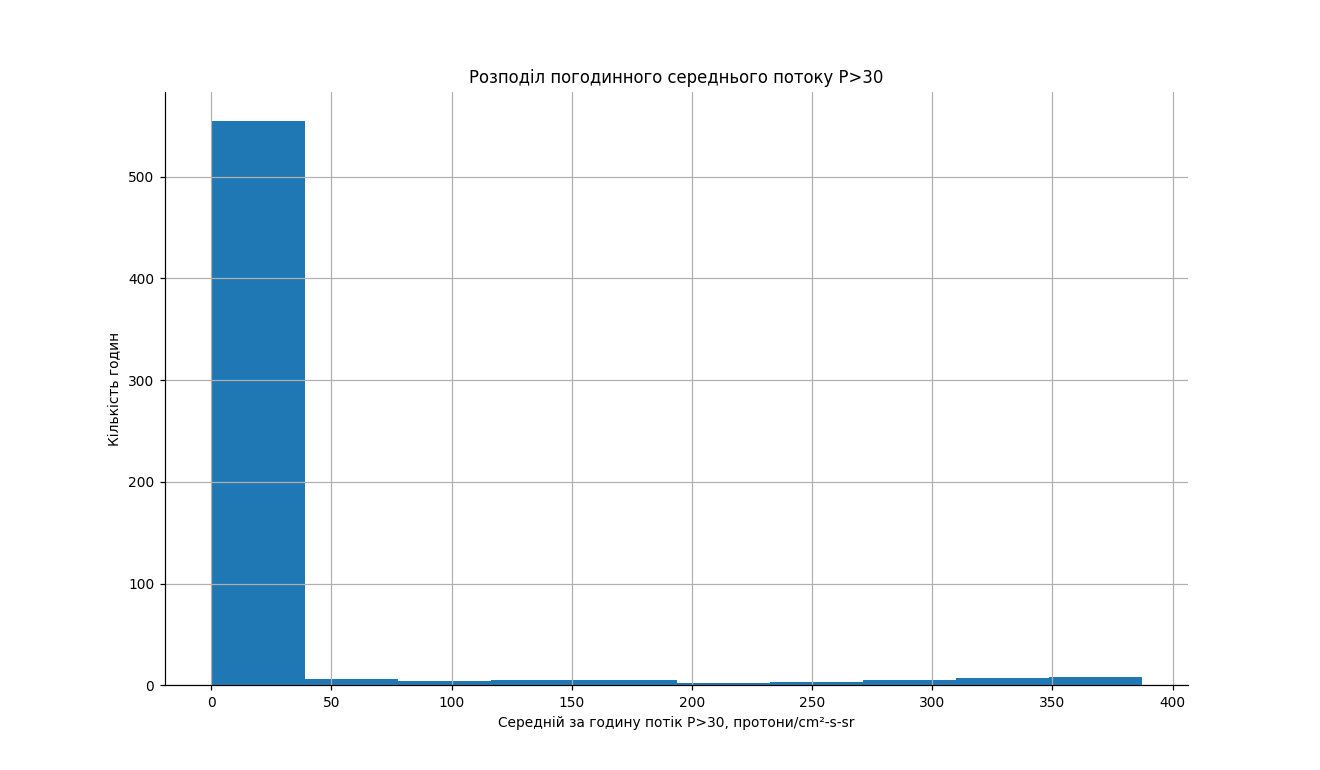

In [20]:
# ВАШ КОД
plt.figure(figsize=(12, 7))

plt.hist(M["protons_gt_30MeV"].dropna())

plt.xlabel("Середній за годину потік P>30, протони/cm²-s-sr")
plt.ylabel("Кількість годин")
plt.title("Розподіл погодинного середнього потоку P>30")
plt.grid()
plt.show()

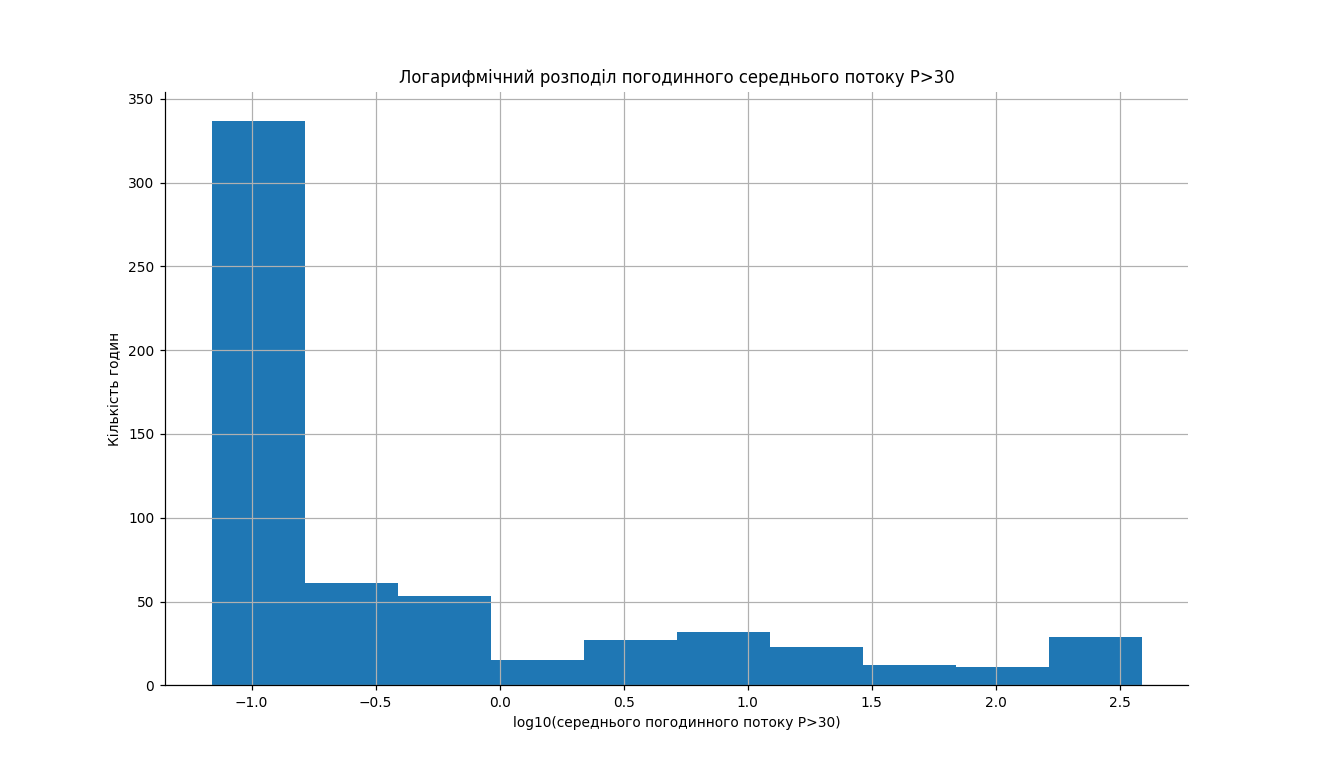

In [21]:

P30 = M["protons_gt_30MeV"].dropna()

P30_log = np.log10(P30[P30 > 0])

plt.figure(figsize=(12, 7))

plt.hist(P30_log)

plt.xlabel("log10(середнього погодинного потоку P>30)")
plt.ylabel("Кількість годин")
plt.title("Логарифмічний розподіл погодинного середнього потоку P>30")
plt.grid()
plt.show()

**Висновок:** бачимо, що більшість погодинних значень P>30 малі, але окремі великі сплески створюють хвіст. Саме це і спричиняє велику різницю між середнім та медіаною

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

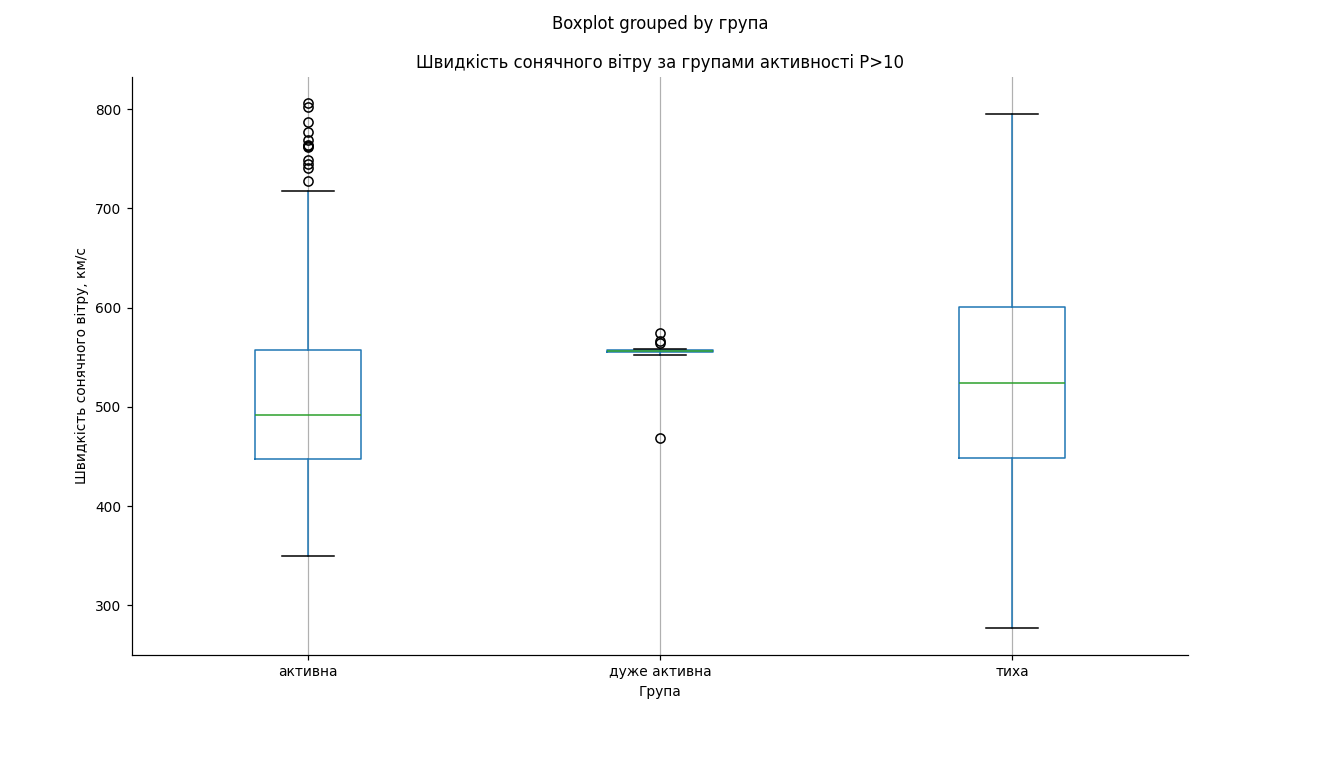

In [22]:
# ВАШ КОД
M.boxplot(
    column="speed_km_s",
    by="група",
    figsize=(12,7)
)

plt.title("Швидкість сонячного вітру за групами активності P>10")
plt.xlabel("Група")
plt.ylabel("Швидкість сонячного вітру, км/с")
plt.grid(axis="y")
plt.show()

**Висновок:** швидкість сонячного вітру між групами відрізняється приблизно на 50 км/с, але загалом графіки перекриваються

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Кореляція 0.28528892999766575


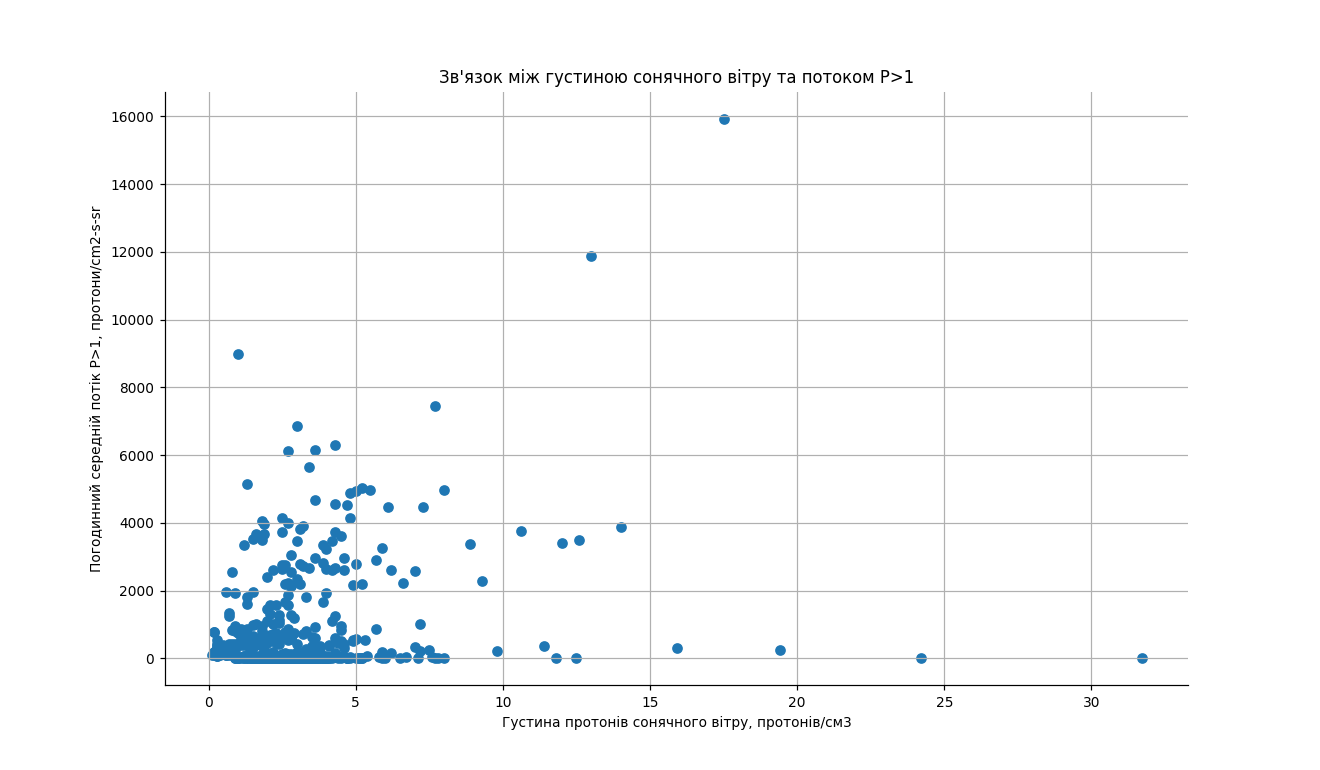

In [23]:
# ВАШ КОД
data = M[["density_protons_cm3", "protons_gt_1MeV"]].dropna()

r = data["density_protons_cm3"].corr(data["protons_gt_1MeV"])
print("Кореляція", r)

plt.figure(figsize=(12, 7))

plt.scatter(
    data["density_protons_cm3"],
    data["protons_gt_1MeV"],
)

plt.xlabel("Густина протонів сонячного вітру, протонів/см3")
plt.ylabel("Погодинний середній потік P>1, протони/cm2-s-sr")
plt.title("Зв'язок між густиною сонячного вітру та потоком P>1")
plt.grid()

plt.show()

**Висновок:** хоч і коефіцієнт кореляції 0.28, що свідчить за слабкий позитивний зв'язок, але на діаграмі видно значне розсіювання, особливо при низьких значеннях

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

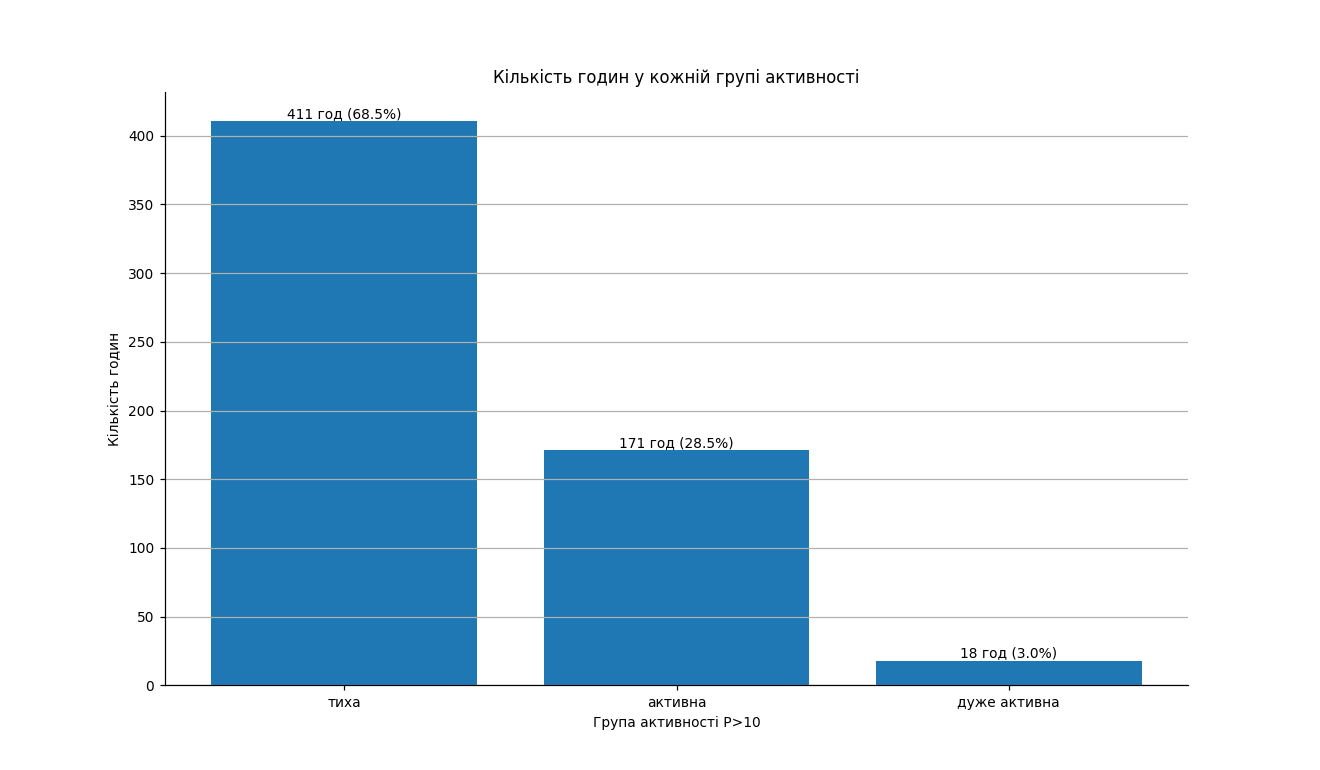

In [24]:
# ВАШ КОД
counts = M["група"].value_counts()
percent = counts / counts.sum() * 100
# print(percent)

plt.figure(figsize=(12,7))
bars = plt.bar(counts.index, counts.values)

plt.xlabel("Група активності P>10")
plt.ylabel("Кількість годин")
plt.title("Кількість годин у кожній групі активності")

for bar, count, pct in zip(bars, counts, percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count} год ({pct:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y")
plt.show()

**Висновок:** найбільшу частку годин займає тиха група 68.5%, потім активна 28.5% і дуже активна 3%

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

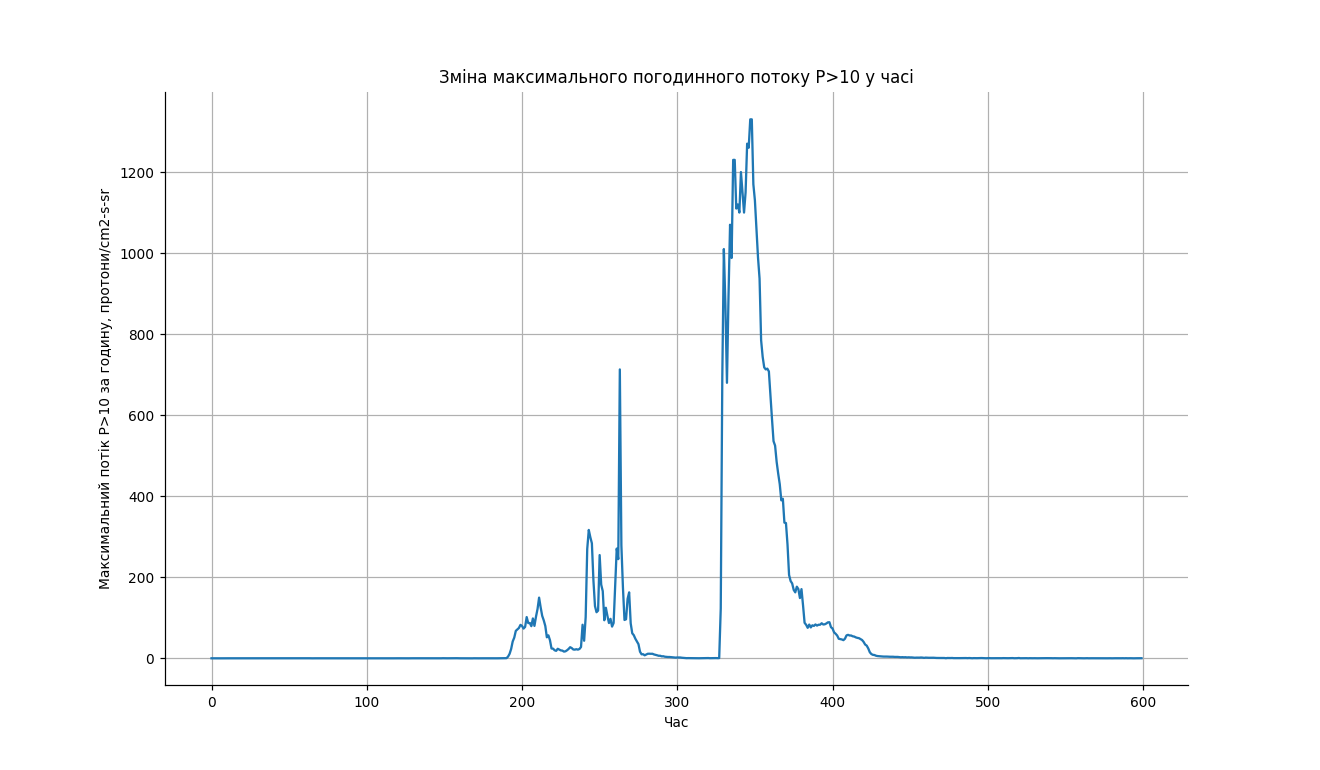

In [25]:
# ВАШ КОД
plt.figure(figsize=(12,7))

plt.plot(M["P10_max"].index, M["P10_max"].values)

plt.xlabel("Час")
plt.ylabel("Максимальний потік P>10 за годину, протони/cm2-s-sr")
plt.title("Зміна максимального погодинного потоку P>10 у часі")
plt.grid()
plt.show()

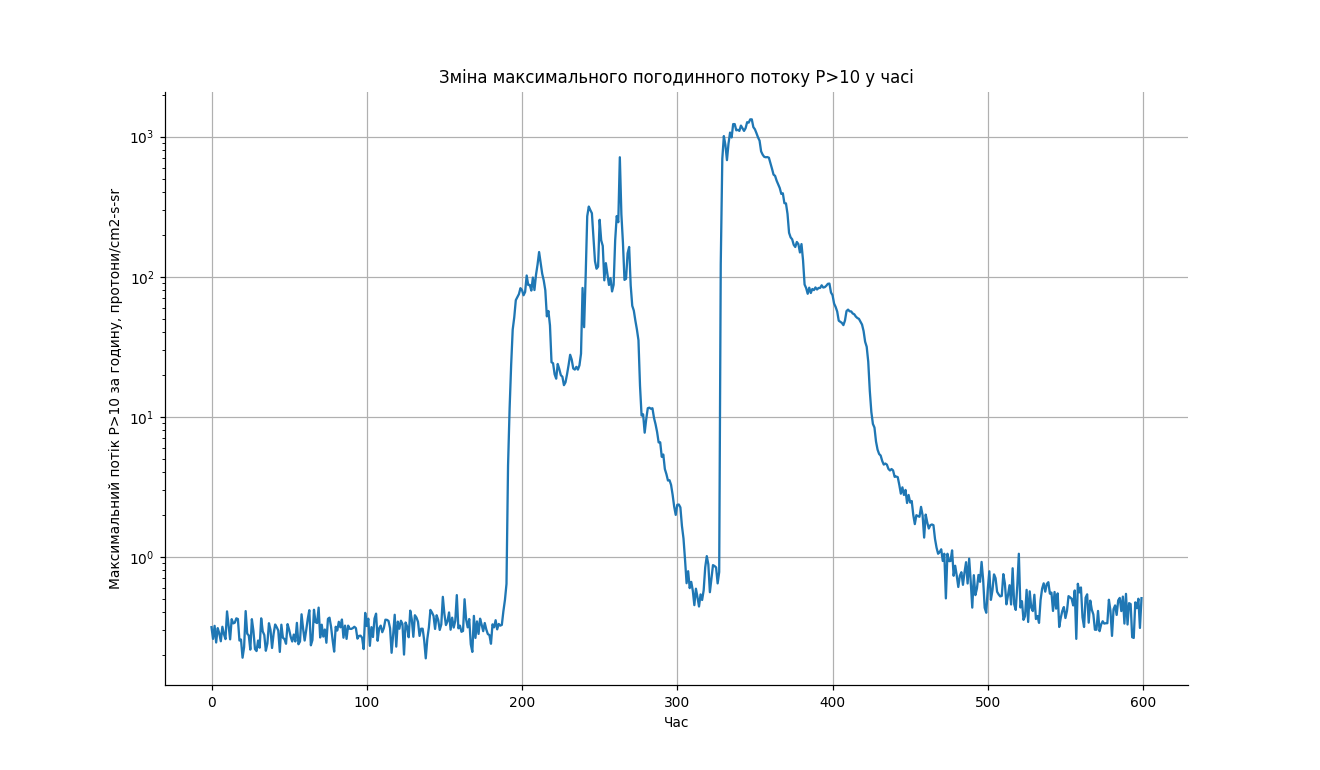

In [26]:
plt.figure(figsize=(12, 7))

plt.plot(
    M["P10_max"].index,
    M["P10_max"].values
)

plt.yscale("log")
plt.xlabel("Час")
plt.ylabel("Максимальний потік P>10 за годину, протони/cm2-s-sr")
plt.title("Зміна максимального погодинного потоку P>10 у часі")
plt.grid()

plt.show()

**Висновок:** бачимо, що за весь час відбулось згруба два великі сплески, в інші моменти потік P>10 був низький

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

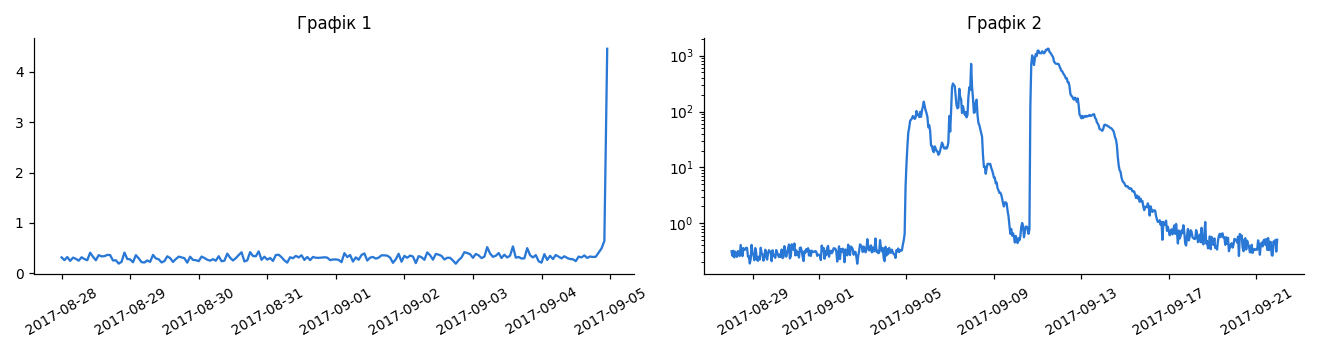

In [27]:
СТОВПЕЦЬ = 'P10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: людина побачить лише початок періоду спостережень, на якому немає значних сплесків
2. Висновок з другого графіка: людина побачить весь проміжок часу і зможе ясно дати оцінку сонячних вітрів, а логарифмічна шкала дозволить краще побачити сплески
3. Дві відмінності між ними: перший графік показує лише 28.08–05.09, другий - весь період спостережень; перший графік має лінійну шкалу Y, другий - логарифмічну шкалу Y


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

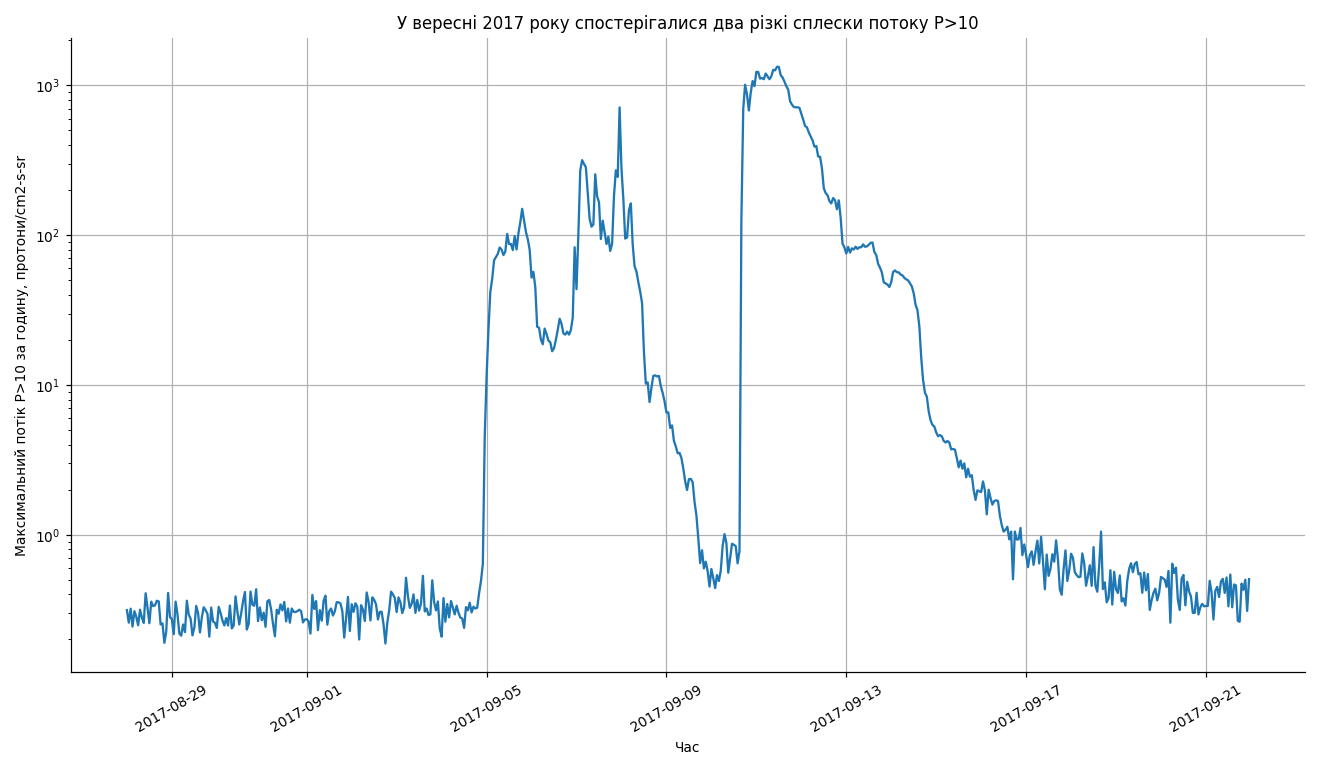

In [28]:
# ВАШ КОД
plt.figure(figsize=(12, 7))

plt.plot(
    M["ts"],
    M["P10_max"]
)

plt.yscale("log")

plt.xlabel("Час")
plt.ylabel("Максимальний потік P>10 за годину, протони/cm2-s-sr")

plt.title("У вересні 2017 року спостерігалися два різкі сплески потоку P>10")

plt.grid()
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Відповідь 6.2:** я обрав саме цей графік, бо він показує повний період спостереження. для осі Y використано логарифмічну шкалу, яка чітко показує два сплески. такий масштаб дозволяє одночасно побачити як і великі, так і малі зміни потоку, а заголовок сформовано як висновок з даних

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** у таблиці A лише 3 пропуски з 7200, що означає, що прилад станції дає похибку лише в 0,0004% випадках. видно у завданні 3.1

**Спостереження 2:** від'ємні -1 у таблиці C з'явились одночасно у двох значеннях speed_km_s та density_protons_cm3 та в один проміжок часу. це означає, що збій торкнувся обох величин одночасно. видно у 3.2 

**Спостереження 3:** outer об'єднання дало 24 пропуски саме у стовпці F10_7. це одначає, що таблиця B складається лише з періоду за 25 діб і не покриває крайні години вікна спостережень. видно в завданні 4.3


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [29]:
# ВАШ КОД
P30_mean_daily = M.set_index("ts")["protons_gt_30MeV"].resample("1D").mean()
# print(P30_mean_daily)

print("Максимум", P30_mean_daily.idxmax().date(), P30_mean_daily.max())
print("Мінімум", P30_mean_daily.idxmin().date(), P30_mean_daily.min())

Максимум 2017-09-11 292.93055555555554
Мінімум 2017-09-01 0.08973368055555557


**Відповідь 7.2:** найбільше середньодобове значення для P>30 було 11 вересня і становило 292.93, а найменше - 1 вересня і становило 0.0897. різниця між ними становить аж 3265 разів! 

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [30]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'ні',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'синтаксис',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = "Перевіряв одиниці виміру на етапі 1-2; дивився багато синтаксису під час об'єднання таблиць та їх поділ; дивився на синтаксис створення різних типів графіків; переформульовував висновки на етапі 6-7"

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [31]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Штурин Захарій Михайлович
інструменти:                                   ChatGPT
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        ні
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     синтаксис
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Перевіряв одиниці виміру на етапі 1-2; дивився багато синтаксису під час об'єднання таблиць та їх поділ; дивився на синтаксис створення різних типів графіків; переформульовував висновки на етапі 6-7
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [32]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 14)


In [33]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
